# Comparative Analysis of Insulin Protein Sequences Across Species Using Biopython

## 1. Project Overview

This project looks at insulin protein sequences from different species and compares them using Biopython. The goal is to see how similar these sequences are and whether insulin stays mostly the same, or is conserved, across species.

 **Research Question:**
How similar are insulin protein sequences across selected species, and what does this suggest about the biological conservation of insulin?

## 2. Install and Import Required Tools

In [4]:
#install biopython, a library used for reading and analysing protein sequences
!pip install biopython

In [5]:
from google.colab import files # Used to upload files
from Bio import SeqIO # Read FASTA files
from Bio.SeqUtils.ProtParam import ProteinAnalysis # Calculate protein properties
from Bio.Align import PairwiseAligner # Compare protein sequences
import pandas as pd
import matplotlib.pyplot as plt

## 3. Upload and Read FASTA Files

In [6]:
uploaded = files.upload() # Opens file-upload box

Saving cow_insulin.fasta to cow_insulin.fasta
Saving human_insulin.fasta to human_insulin.fasta
Saving mouse_insulin.fasta to mouse_insulin.fasta
Saving zebrafish_insulin.fasta to zebrafish_insulin.fasta


In [8]:
#  List the sequence files I want to work with
file_names = ["human_insulin.fasta", "mouse_insulin.fasta", "cow_insulin.fasta", "zebrafish_insulin.fasta"]

# Create an empty dictionary to store the sequence records
sequence_records = {}

# Read each FASTA file and store its sequence record
for file in file_names:
    sequence_details = SeqIO.read(file, "fasta")
    sequence_records[file] = sequence_details


In [13]:
# Print the file name, sequence ID, description, and sequence length for each file
for name, sequence_details in sequence_records.items():
    print(name)
    print("ID:", sequence_details.id)
    print("Description:", sequence_details.description)
    print("Sequence length:", len(sequence_details.seq))
    print("-" * 50)

human_insulin.fasta
ID: sp|P01308|INS_HUMAN
Description: sp|P01308|INS_HUMAN Insulin OS=Homo sapiens OX=9606 GN=INS PE=1 SV=1
Sequence length: 110
--------------------------------------------------
mouse_insulin.fasta
ID: sp|P01325|INS1_MOUSE
Description: sp|P01325|INS1_MOUSE Insulin-1 OS=Mus musculus OX=10090 GN=Ins1 PE=1 SV=1
Sequence length: 108
--------------------------------------------------
cow_insulin.fasta
ID: sp|P01317|INS_BOVIN
Description: sp|P01317|INS_BOVIN Insulin OS=Bos taurus OX=9913 GN=INS PE=1 SV=2
Sequence length: 105
--------------------------------------------------
zebrafish_insulin.fasta
ID: sp|O73727|INS_DANRE
Description: sp|O73727|INS_DANRE Insulin OS=Danio rerio OX=7955 GN=ins PE=3 SV=1
Sequence length: 108
--------------------------------------------------


The uploaded FASTA files were parsed using Biopython. Each record contains a protein sequence and metadata such as the sequence ID and description.

## 4. Basic Sequence Summary

In [15]:
# Create an empty list to collect summary information
summary = []

# Go through each sequence and store its file name and length
for name, sequence_details in sequence_records.items():
    sequence = str(sequence_details.seq) # Convert sequence into normal text string

    summary.append({ "Species_File": name, "Sequence_Length": len(sequence) })

# Turn the summary list into a table
summary_table = pd.DataFrame(summary)

# View the summary table
summary_table

,Species_File,Sequence_Length
0,human_insulin.fasta,110
1,mouse_insulin.fasta,108
2,cow_insulin.fasta,105
3,zebrafish_insulin.fasta,108


## 5. Protein Property Analysis

In [16]:
# Create an empty list to collect properties of protein
properties = []

# Analyse each sequence and calculate protein associated properties
for name, sequence_details in sequence_records.items():
    sequence = str(sequence_details.seq)
    protein_analysis = ProteinAnalysis(sequence) # Creates a tool that can analyse the protein

    properties.append({ "Species_File": name, "Length": len(sequence), "Molecular_Weight": protein_analysis.molecular_weight(), "Aromaticity": protein_analysis.aromaticity(), "Instability_Index": protein_analysis.instability_index(), "Isoelectric_Point": protein_analysis.isoelectric_point() })

# Turn the properties list into a table
properties_table = pd.DataFrame(properties)

# View the properties table
properties_table

,Species_File,Length,Molecular_Weight,Aromaticity,Instability_Index,Isoelectric_Point
0,human_insulin.fasta,110,11980.7866,0.081818,40.332818,5.218581
1,mouse_insulin.fasta,108,12160.0224,0.083333,40.463981,5.522613
2,cow_insulin.fasta,105,11393.1520,0.085714,37.176286,7.599566
3,zebrafish_insulin.fasta,108,11903.6793,0.092593,33.759352,6.023080


Basic protein properties were calculated using Biopython’s ProteinAnalysis module. These values help compare the sequences across species and show that even conserved proteins can still differ slightly in their biochemical properties.

## 6. Pairwise Sequence Comparison

In [17]:
# Store the human insulin sequence as the reference sequence
human_seq = str(sequence_records["human_insulin.fasta"].seq)

# Create a pairwise aligner for sequence comparison
aligner = PairwiseAligner()

# Use global alignment (vs. local)
aligner.mode = "global"

# Give 1 point for a when there is a match
aligner.match_score = 1

# Give 0 points for a mismatch
aligner.mismatch_score = 0

# No penalty for gaps in this simple comparison (allow the gaps)
aligner.open_gap_score = 0
aligner.extend_gap_score = 0

In [18]:
# Create an empty list to collect comparison results
results = []

# Compare each sequence to human insulin
for name, sequence_details in sequence_records.items():
    current_sequence = str(sequence_details.seq)

    alignment = aligner.align(human_seq, current_sequence)[0]
    score = alignment.score
    max_length = max(len(human_seq), len(current_sequence))
    percent_sim = (score / max_length) * 100

    results.append({ "Compared_To_Human": name, "Alignment_Score": score, "Percent_Similarity": percent_sim })

# Turn the comparison results into a table
comparison_table = pd.DataFrame(results)

# View the comparison table
comparison_table

,Compared_To_Human,Alignment_Score,Percent_Similarity
0,human_insulin.fasta,110.0,100.000000
1,mouse_insulin.fasta,87.0,79.090909
2,cow_insulin.fasta,88.0,80.000000
3,zebrafish_insulin.fasta,61.0,55.454545


Each insulin sequence was compared with the human insulin sequence using pairwise alignment. A higher percent identity suggests that the sequence has remained more conserved across species.

## 7. Visualisation

In [20]:
# To simplify species labels for better readability in the bar chart
label_names = { "human_insulin.fasta": "Human", "mouse_insulin.fasta": "Mouse", "cow_insulin.fasta": "Cow", "zebrafish_insulin.fasta": "Zebrafish" }

comparison_table["Species"] = comparison_table["Compared_To_Human"].replace(label_names)

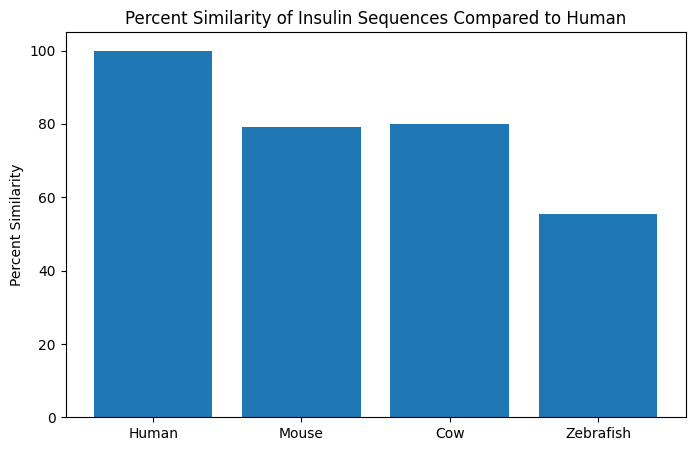

In [21]:
# Plot the similarity of each insulin sequence compared to human insulin
plt.figure(figsize=(8, 5))
plt.bar(comparison_table["Species"], comparison_table["Percent_Similarity"])

plt.title("Percent Similarity of Insulin Sequences Compared to Human")
plt.ylabel("Percent Similarity")
plt.show()

## 8. Key Findings

- The insulin protein sequences appeared to be highly conserved across species, especially among the mammalian ones.
- When compared with the human insulin sequence, some species showed a stronger similarity than others.
- Basic protein properties such as molecular weight and isoelectric point were also fairly similar across the sequences, which further reflects the biological conservation of insulin.
- This project helped me get introduced to working with FASTA files, reading and parsing sequences, analysing protein properties, and performing simple pairwise sequence comparison using Biopython.